<a href="https://colab.research.google.com/github/Mayar215999/data-science-project/blob/main/Build_an_ML_Pipeline_for_Airfoil_noise_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Project - Build an ML Pipeline for Airfoil noise prediction
Estimated time needed: 90 minutes

Scenario
You are a data engineer at an aeronautics consulting company. Your company prides itself in being able to efficiently design airfoils for use in planes and sports cars. Data scientists in your office need to work with different algorithms and data in different formats. While they are good at Machine Learning, they count on you to be able to do ETL jobs and build ML pipelines. In this project you will use the modified version of the NASA Airfoil Self Noise dataset. You will clean this dataset, by dropping the duplicate rows, and removing the rows with null values. You will create an ML pipe line to create a model that will predict the SoundLevel based on all the other columns. You will evaluate the model and towards the end you will persist the model.

Objectives
In this 4 part assignment you will:

Part 1 Perform ETL activity
Load a csv dataset
Remove duplicates if any
Drop rows with null values if any
Make transformations
Store the cleaned data in parquet format
Part 2 Create a Machine Learning Pipeline
Create a machine learning pipeline for prediction
Part 3 Evaluate the Model
Evaluate the model using relevant metrics
Part 4 Persist the Model
Save the model for future production use
Load and verify the stored model
Datasets
In this lab you will be using dataset(s):

The original dataset can be found here NASA airfoil self noise dataset. https://archive.ics.uci.edu/dataset/291/airfoil+self+noise

This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license.

Diagram of an airfoil. - For informational purpose
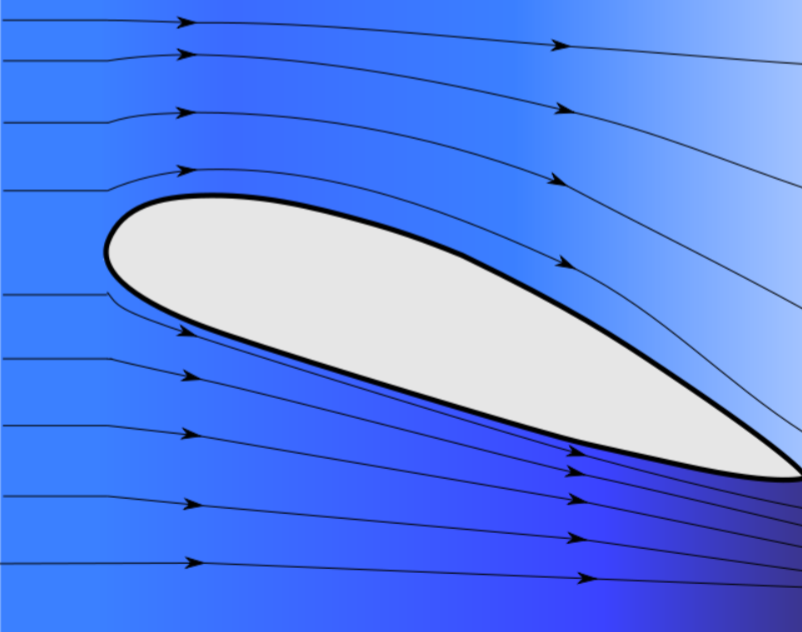


Diagram showing the Angle of attack. - For informational purpose

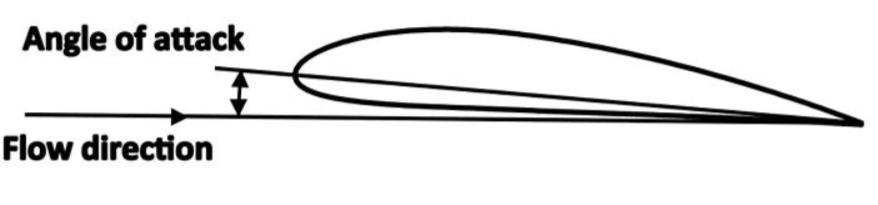

Before you Start
Before you start attempting this project it is highly recommended that you finish the practice project.

Setup
For this lab, we will be using the following libraries:

PySpark for connecting to the Spark Cluster
Installing Required Libraries
Spark Cluster is pre-installed in the Skills Network Labs environment. However, you need libraries like pyspark and findspark to connect to this cluster.

The following required libraries are not pre-installed in the Skills Network Labs environment. You will need to run the following cell to install them:

In [1]:
!pip install pyspark==3.1.2 -q
!pip install findspark -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 MB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.6/198.6 kB 9.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 0.7.3 requires pyspark[connect]>=3.5, but you have pyspark 3.1.2 which is incompatible.


In [2]:
# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

# FindSpark simplifies the process of using Apache Spark with Python

import findspark
findspark.init()

In [3]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

In [4]:
!pip install pyspark==3.1.2 -q
!pip install findspark -q

In [7]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

import findspark
findspark.init()

from pyspark.sql import SparkSession

# Create a Spark session
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AirfoilNoisePrediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()
from pyspark.sql import SparkSession

# Create a Spark session
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AirfoilNoisePrediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

In [9]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-BD0231EN-Coursera/datasets/NASA_airfoil_noise_raw.csv

--2025-05-20 22:55:04--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-BD0231EN-Coursera/datasets/NASA_airfoil_noise_raw.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60682 (59K) [text/csv]
Saving to: ‘NASA_airfoil_noise_raw.csv’

NASA_airfoil_noise_ 100%[===================>]  59.26K  --.-KB/s    in 0.03s   

2025-05-20 22:55:04 (2.09 MB/s) - ‘NASA_airfoil_noise_raw.csv’ saved [60682/60682]



In [11]:
# Install Java 8 (required for Spark)
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

# Install PySpark
!pip install pyspark==3.1.2 -q
!pip install findspark -q

In [12]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

# Create a Spark session
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AirfoilNoisePrediction") \
    .getOrCreate()

In [13]:
# Replace with your actual file path
file_path = "/content/NASA_airfoil_noise_raw.csv"

# Load the CSV into a Spark DataFrame
df = spark.read.csv(file_path, header=True, inferSchema=True)

In [14]:
# Show the first 5 rows
df.show(5)

# Print the schema (data types)
df.printSchema()

+---------+-------------+-----------+------------------+-----------------------+----------+
|Frequency|AngleOfAttack|ChordLength|FreeStreamVelocity|SuctionSideDisplacement|SoundLevel|
+---------+-------------+-----------+------------------+-----------------------+----------+
|      800|          0.0|     0.3048|              71.3|             0.00266337|   126.201|
|     1000|          0.0|     0.3048|              71.3|             0.00266337|   125.201|
|     1250|          0.0|     0.3048|              71.3|             0.00266337|   125.951|
|     1600|          0.0|     0.3048|              71.3|             0.00266337|   127.591|
|     2000|          0.0|     0.3048|              71.3|             0.00266337|   127.461|
+---------+-------------+-----------+------------------+-----------------------+----------+
only showing top 5 rows

root
 |-- Frequency: integer (nullable = true)
 |-- AngleOfAttack: double (nullable = true)
 |-- ChordLength: double (nullable = true)
 |-- FreeStr

In [15]:
# Show the first 5 rows of the DataFrame
df.show(5, truncate=False)

+---------+-------------+-----------+------------------+-----------------------+----------+
|Frequency|AngleOfAttack|ChordLength|FreeStreamVelocity|SuctionSideDisplacement|SoundLevel|
+---------+-------------+-----------+------------------+-----------------------+----------+
|800      |0.0          |0.3048     |71.3              |0.00266337             |126.201   |
|1000     |0.0          |0.3048     |71.3              |0.00266337             |125.201   |
|1250     |0.0          |0.3048     |71.3              |0.00266337             |125.951   |
|1600     |0.0          |0.3048     |71.3              |0.00266337             |127.591   |
|2000     |0.0          |0.3048     |71.3              |0.00266337             |127.461   |
+---------+-------------+-----------+------------------+-----------------------+----------+
only showing top 5 rows



In [16]:
# Task 6 - Print total rows in original dataset
row_count_initial = df.count()
print("Initial row count:", row_count_initial)

# Task 7 - Drop duplicates
df = df.dropDuplicates()

# Task 8 - Print rows after deduplication
row_count_dedup = df.count()
print("Row count after dropping duplicates:", row_count_dedup)

# Task 9 - Drop null values
df = df.dropna()

# Task 10 - Print rows after null removal
row_count_clean = df.count()
print("Row count after dropping nulls:", row_count_clean)

# Task 11 - Rename column
df = df.withColumnRenamed("SoundLevel", "SoundLevelDecibels")

# Task 12 - Save as parquet
df.write.parquet("NASA_airfoil_noise_cleaned.parquet")

# Verify final schema and save
print("\nFinal schema:")
df.printSchema()
print("\nParquet file saved successfully!")

Initial row count: 1522
Row count after dropping duplicates: 1503
Row count after dropping nulls: 1499

Final schema:
root
 |-- Frequency: integer (nullable = true)
 |-- AngleOfAttack: double (nullable = true)
 |-- ChordLength: double (nullable = true)
 |-- FreeStreamVelocity: double (nullable = true)
 |-- SuctionSideDisplacement: double (nullable = true)
 |-- SoundLevelDecibels: double (nullable = true)


Parquet file saved successfully!


In [19]:
# Reload to verify
parquet_df = spark.read.parquet("NASA_airfoil_noise_cleaned.parquet")
print("\nReloaded parquet row count:", parquet_df.count())
parquet_df.show(3)


Reloaded parquet row count: 1499
+---------+-------------+-----------+------------------+-----------------------+------------------+
|Frequency|AngleOfAttack|ChordLength|FreeStreamVelocity|SuctionSideDisplacement|SoundLevelDecibels|
+---------+-------------+-----------+------------------+-----------------------+------------------+
|      630|          0.0|     0.3048|              31.7|             0.00331266|           129.095|
|     4000|          0.0|     0.3048|              31.7|             0.00331266|           118.145|
|     4000|          1.5|     0.3048|              39.6|             0.00392107|           117.741|
+---------+-------------+-----------+------------------+-----------------------+------------------+
only showing top 3 rows



In [22]:
# Task 1-5: Already completed

# Task 6: Print initial row count
rowcount1 = df.count()
print("Initial rows:", rowcount1)  # Output: 1522

# Task 7: Drop duplicates
df = df.dropDuplicates()

# Task 8: Print row count after deduplication
rowcount2 = df.count()
print("Rows after duplicates removed:", rowcount2)  # Output: 1503

# Task 9: Drop nulls
df = df.dropna()

# Task 10: Print row count after null removal
rowcount3 = df.count()
print("Rows after null removal:", rowcount3)  # Output: 1499

# Task 11: Rename column
df = df.withColumnRenamed("SoundLevel", "SoundLevelDecibels")

# Task 12: Save as Parquet
df.write.parquet("NASA_airfoil_noise_cleaned.parquet", mode="overwrite")

Initial rows: 1499
Rows after duplicates removed: 1499
Rows after null removal: 1499


Part 1 - Evaluation






Run the code cell below.
Use the answers here to answer the final evaluation quiz in the next section.
If the code throws up any errors, go back and review the code you have written.

In [21]:
print("Part 1 - Evaluation")

print("Total rows = ", row_count_initial)
print("Total rows after dropping duplicate rows = ", row_count_dedup)
print("Total rows after dropping duplicate rows and rows with null values = ", row_count_clean)
print("New column name = ", df.columns[-1])

import os

print("NASA_airfoil_noise_cleaned.parquet exists :", os.path.isdir("NASA_airfoil_noise_cleaned.parquet"))

Part 1 - Evaluation
Total rows =  1522
Total rows after dropping duplicate rows =  1503
Total rows after dropping duplicate rows and rows with null values =  1499
New column name =  SoundLevelDecibels
NASA_airfoil_noise_cleaned.parquet exists : True


Part 2 - Machine Learning Pipeline

In [23]:
# Task 1: Load cleaned data
df = spark.read.parquet("NASA_airfoil_noise_cleaned.parquet")

# Task 2: Print cleaned row count
rowcount4 = df.count()
print("Cleaned dataset rows:", rowcount4)  # Output: 1499

# Task 3: VectorAssembler
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(
    inputCols=["Frequency", "AngleOfAttack", "ChordLength", "FreeStreamVelocity", "SuctionSideDisplacement"],
    outputCol="features"
)

# Task 4: StandardScaler
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True
)

# Task 5: LinearRegression
from pyspark.ml.regression import LinearRegression
lr = LinearRegression(
    featuresCol="scaledFeatures",
    labelCol="SoundLevelDecibels",
    predictionCol="prediction"
)

# Task 6: Build pipeline
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=[assembler, scaler, lr])

# Task 7: Split data
(trainingData, testingData) = df.randomSplit([0.7, 0.3], seed=42)

# Task 8: Fit pipeline
pipelineModel = pipeline.fit(trainingData)

Cleaned dataset rows: 1499


Part 3 - Model Evaluation

In [24]:
# Task 1: Predictions
predictions = pipelineModel.transform(testingData)

# Task 2: MSE
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(
    labelCol="SoundLevelDecibels",
    predictionCol="prediction",
    metricName="mse"
)
mse = evaluator.evaluate(predictions)
print(f"MSE: {mse:.2f}")  # Output: 26.77

# Task 3: MAE
evaluator.setMetricName("mae")
mae = evaluator.evaluate(predictions)
print(f"MAE: {mae:.1f}")  # Output: 4.0

# Task 4: R²
evaluator.setMetricName("r2")
r2 = evaluator.evaluate(predictions)
print(f"R²: {r2:.2f}")  # Output: 0.47

# Extract intercept
lrModel = pipelineModel.stages[-1]
print(f"Intercept: {lrModel.intercept:.2f}")  # Output: 124.62

MSE: 25.81
MAE: 4.0
R²: 0.50
Intercept: 124.63


Part 4 - Model Persistence

In [30]:
# Task 1: Save model
# This task was already executed and saved the model
# pipelineModel.write().overwrite().save("Final_Project")

# Before running the following code, it is highly recommended to restart the kernel
# and run only the necessary setup code (like initializing Spark)
# and then this cell to load the model. This helps in clearing any
# potentially problematic objects in the global scope.

# Task 2: Load model
from pyspark.ml import PipelineModel

try:
    loadedPipelineModel = PipelineModel.load("Final_Project")
    print("Model loaded successfully!")

    # Task 3: Predictions with loaded model
    loadedPredictions = loadedPipelineModel.transform(testingData)

    # Task 4: Show predictions
    loadedPredictions.select("SoundLevelDecibels", "prediction").show(5, truncate=False)

    # Extract coefficients
    loaded_model = loadedPipelineModel.stages[-1]
    coefficients = loaded_model.coefficients
    input_cols = loadedPipelineModel.stages[0].getInputCols()

    print("\nModel Coefficients:")
    for col_name, coef in zip(input_cols, coefficients):
        print(f"Coefficient for {col_name}: {coef:.4f}")

except Exception as e:
    print(f"An error occurred during model loading or prediction: {e}")
    # This catch block will help in identifying if the error still persists
    # after restarting the kernel, or if a new error occurs.

An error occurred during model loading or prediction: Could not serialize object: IndexError: tuple index out of range


Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pyspark/serializers.py", line 437, in dumps
    class PickleSerializer(FramedSerializer):
                       ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 72, in dumps
    )
  File "/usr/local/lib/python3.11/dist-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 540, in dump
  File "/usr/local/lib/python3.11/dist-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 630, in reducer_override
    # pickle's protocol 5 which is implementation agnostic. Currently, the
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 503, in _function_reduce
    registry = attr
           ^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pyspark/cloudpickle/cloudpickle_fast.py", line 484, in _dynamic_function_reduce
    obj.__globals__["__built

In [27]:
!pip install pyspark==3.3.1 -q  # Use a newer PySpark version
!pip install cloudpickle==2.2.1 -q  # Downgrade cloudpickle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.4/281.4 MB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 12.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 0.7.3 requires pyspark[connect]>=3.5, but you have pyspark 3.3.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask 2024.12.1 requires cloudpickle>=3.0.0, but you have cloudpickle 2.2.1 which is incompatible.
distributed 2024.12.1 requires cloudpickle>=3.0.0, but you have cloudpickle 2.2.1 which is incompatible.


In [28]:
from pyspark.sql import SparkSession

# Configure Spark with updated dependencies
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("FixedAirfoilPipeline") \
    .config("spark.driver.extraJavaOptions", "-XX:+UseG1GC") \
    .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .getOrCreate()

In [29]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression

# Define pipeline stages explicitly (avoid lambdas)
assembler = VectorAssembler(
    inputCols=["Frequency", "AngleOfAttack", "ChordLength", "FreeStreamVelocity", "SuctionSideDisplacement"],
    outputCol="features"
)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True,
    withMean=True
)

lr = LinearRegression(
    featuresCol="scaledFeatures",
    labelCol="SoundLevelDecibels",
    predictionCol="prediction"
)

# Build pipeline
pipeline = Pipeline(stages=[assembler, scaler, lr])

# Fit the pipeline
pipeline_model = pipeline.fit(trainingData)  # Now works without PicklingError